# Lab 5A - TD prediction with random walk


## 1. Objectives

In [1]:
import matplotlib.pyplot as plt
import numpy as np


## 2. Random Walk Environment (Sutton & Barto, Example 6.2)

In this lab, we study Temporal-Difference (TD) prediction using a classic benchmark introduced in  
*Reinforcement Learning: An Introduction* by Sutton & Barto (Example 6.2).  
This simple environment is designed to clearly illustrate the core idea of bootstrapping, which is central to TD learning.

### 2.1 Environment Description

The environment consists of a one-dimensional random walk with five non-terminal states arranged in a line:

`T_L — A — B — C — D — E — T_R`

where
- A, B, C, D, E are non-terminal states.
- T_L (left terminal) and T_R (right terminal) are absorbing terminal states.

At each time step, the agent follows a fixed policy $\pi$:
- With probability 0.5, it moves one state to the `LEFT` (`action=0`).
- With probability 0.5, it moves one state to the `RIGHT` (`action=1`).

The episode starts in the center state C and terminates when either terminal state is reached.



### 2.2 Rewards and Discount Factor

- Walking into T_R : reward = +1.
- Walking into T_L : reward of 0.
- All other transitions give 0 reward.
- The discount factor is set to  $\gamma = 1$, since episodes are finite and always terminate.



### 2.3 Learning Objective

The goal is **not to learn an optimal policy**, but to estimate the **state-value function**
$$
V_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s],
$$
for the fixed random policy described above.

In this environment, the return $G_t$ is either **0 or 1**, depending on which terminal state is reached.  



**Exercise 1.** Prove that, in this environment, when following the random policy $\pi$ (moving left or right with equal probability), the true state-value function satisfies
$$
V_\pi(A)=\tfrac{1}{6},\;
V_\pi(B)=\tfrac{2}{6},\;
V_\pi(C)=\tfrac{3}{6},\;
V_\pi(D)=\tfrac{4}{6},\;
V_\pi(E)=\tfrac{5}{6}.
$$


-----------

In the following, we implement this environment as a Python class with three main methods:
- `reset()` to start a new episode,
- `step()` to apply an action and observe the next state and reward,
- `is_terminal()` to detect episode termination.

In [2]:
class RandomWalkEnv:
    """Random Walk environment (Sutton & Barto, Example 6.2).

    States:
        0 : left terminal
        1-5 : A, B, C, D, E
        6 : right terminal

    Actions:
        0 : LEFT
        1 : RIGHT
    """

    def __init__(
        self,
        n_nonterminal: int = 5,
        start_state: int = 3,
        rng: np.random.Generator | None = None,
    ) -> None:
        """Initialize the environment.

        Args:
            n_nonterminal (int): Number of non-terminal states.
            start_state (int): Initial state at the beginning of each episode.
            rng (np.random.Generator, optional): Random number generator.

        """
        self.n_nonterminal = n_nonterminal
        self.start_state = start_state
        self.rng = rng if rng is not None else np.random.default_rng(0)

    def reset(self) -> int:
        """Reset the environment and return the start state."""
        return self.start_state

    def is_terminal(self, s: int) -> bool:
        """Return True if state s is terminal."""
        return (s == 0) or (s == self.n_nonterminal + 1)

    def step(self, s: int, action: int) -> tuple[int, float, bool]:
        """Take one step in the environment.

        Parameters
        ----------
        s : int
            Current state.
        action : int
            0 = LEFT, 1 = RIGHT.

        Returns
        -------
        s_next : int
            Next state.
        reward : float
            Immediate reward.
        done : bool
            True if the episode has terminated.

        """
        assert not self.is_terminal(s), "Cannot act from a terminal state."  # noqa: S101

        s_next = s - 1 if action == 0 else s + 1

        done = self.is_terminal(s_next)

        reward = 1.0 if (s_next == self.n_nonterminal + 1) else 0.0

        return s_next, reward, done


To interact with the Random Walk environment, we first define the **random policy** introduced in *Sutton & Barto*. Under the random policy, the agent chooses:
- **LEFT** with probability $\tfrac{1}{2}$,
- **RIGHT** with probability $\tfrac{1}{2}$,
independently at each non-terminal state.

The function `random_policy_action` implements this behavior by sampling uniformly between the two actions (`0` for action = left, and `1` for action = right).

 
For the non-terminal states A to E, the true state-value function $V_\pi$ is known :

$$
V_\pi(A)=\tfrac{1}{6},\quad
V_\pi(B)=\tfrac{2}{6},\quad
V_\pi(C)=\tfrac{3}{6},\quad
V_\pi(D)=\tfrac{4}{6},\quad
V_\pi(E)=\tfrac{5}{6}.
$$

These exact values will be used later to evaluate the accuracy and convergence of Monte Carlo and Temporal-Difference learning methods.


In [3]:
def random_policy_action(rng: np.random.Generator) -> int:
    """Random policy: choose LEFT or RIGHT with probability 1/2."""
    return int(rng.integers(0, 2))  # 0 or 1


# test if random_policy_action is correctly defined
test_action = random_policy_action(np.random.default_rng(1))
print(test_action)

0


In [4]:
# True values for A,B,C,D,E under the random policy (Sutton & Barto)
TRUE_V = {
    1: 1 / 6,  # A
    2: 2 / 6,  # B
    3: 3 / 6,  # C
    4: 4 / 6,  # D
    5: 5 / 6,  # E
}

Now we define `init_V` which initializes the state-value function `V(s)`.

In [5]:
def init_V() -> np.ndarray:
    """Sutton & Barto common initialization.

    - V(A..E)=0.5
    - Terminal values can be set to 0 (Left) and 1 (Right) since we don't update them
      (or Right=0, Left=0; but we never update terminals anyway).
    """
    V = np.zeros(7)
    V[1:6] = 0.5
    V[0] = 0.0
    V[6] = 0.0
    return V


test_v = init_V()
print(test_v)

[0.  0.5 0.5 0.5 0.5 0.5 0. ]


In the following cell, `generate_episode` simulates one complete episode in the Random Walk environment under the random policy. 

In [6]:
def generate_episode(
    env: RandomWalkEnv,
    rng: np.random.Generator,
) -> tuple[list[int], list[float]]:
    """Generate one episode following the random policy.

    Args:
        env (RandomWalkEnv): The random walk environment.
        rng (np.random.Generator): Random number generator.

    Returns:
        states: includes terminal at end [S0, S1, ..., ST]
        rewards: reward obtained after transition [R1, R2, ..., RT]

    """
    states = [
        env.reset(),
    ]  # Starts a new episode. env.reset() returns the initial state S_0 = 3 = state C;
    # We store it as the first element of the states list.
    rewards = []  # Create an empty list to store rewards. Rewards will be appended as the episode evolves.
    done = False  # done is a boolean flag indicating whether the episode is finished.

    while not done:  # Main interaction loop : This loop keeps stepping through the environment until termination.
        # One iteration of this loop corresponds to one time step t

        s = states[
            -1
        ]  # states[-1] means “the last element of states”, which is the current state S_t
        a = random_policy_action(
            rng,
        )  # This implements the behavior policy. random_policy_action returns 0 (LEFT) or 1 (RIGHT) with probability 1/2 each.
        s_next, r, done = env.step(
            s,
            a,
        )  # This applies the environment dynamics: input: current state s and action a
        # output: s_next = next state S_{t+1}, r = reward R_{t+1}, done = whether S_{t+1} is terminal
        states.append(s_next)  # Add the new state to the trajectory.
        rewards.append(r)  # Store the reward obtained for this transition.

    return states, rewards


## 3. Monte Carlo Prediction (with constant step size $\alpha$)

In this part, we implement **Monte Carlo (MC) prediction** to estimate the state-value function $V_{\pi}(s)$ of the Random Walk under the random policy.

Recall that Monte Carlo prediction has 3 steps:
1. Generating complete episodes $S_0, S_1, \dots, S_T$ by interacting with the environment.
2. Computing the **return** from each time step,
$$
G_t = \sum_{k=t}^{T-1} \gamma^{k-t} R_{k+1},
$$
which is the total discounted reward collected from time $t$ until termination.
3. Updating the value estimate using an **incremental average** with step-size $\alpha$:
$$
V(S_t) \leftarrow V(S_t) + \alpha\bigl(G_t - V(S_t)\bigr).
$$

In the Random Walk example, we use $\gamma = 1$, and the agent receives reward $1$ only when it reaches the **right terminal state**.
We store the value estimates after each episode to visualize learning and compare with TD(0) later.



**Exercise 2.** (Implement Monte Carlo prediction for random walk)

Complete the function `mc_prediction` that estimates the value function $V_\pi$ using **first-visit Monte Carlo** with a **constant step-size** $\alpha$. There are 4 main tasks

1. **Generate episodes**
   - Simulate an episode using the random policy.
   - Store:
     - a list of visited states `states = [S_0, S_1, ..., S_T]`
     - a list of rewards `rewards = [R_1, R_2, ..., R_T]`

2. **Compute returns**
   For each time step $t \in \{0,\dots,T-1\}$, compute the Monte Carlo return:
   $$
   G_t = \sum_{k=t}^{T-1} \gamma^{k-t} r_k,
   \quad \text{with } \gamma = 1.
   $$
   *Hint:* compute with a backward loop.

3. **First-visit update**
   Update each nonterminal state at its **first visit** with
   $$
   V(s) \leftarrow V(s) + \alpha \big(G_t - V(s)\big).
   $$
   *Hint:* keep a `visited` set to detect whether a state has already been updated in the episode.

4. **Track learning**
   After each episode, store the current estimates for the five nonterminal states (A–E),
   so we can plot how the estimates evolve over time later.




In [7]:
def mc_prediction_first_visit(
    num_episodes: int,
    alpha: float,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """First-visit Monte Carlo prediction (incremental update).

    Goal:
        Estimate V_pi(s) for the Random Walk under the random policy.

    Args:
        num_episodes (int): Number of episodes to sample.
        alpha (float): Step-size parameter (0 < alpha <= 1).
        seed (int): Random seed.

    Returns:
        V: value estimates (table)
        V_history: array of shape (num_episodes, 5) tracking V for states A..E

    """
    rng = np.random.default_rng(seed)
    env = RandomWalkEnv(rng=rng)

    V = init_V()
    V_history = []

    gamma = 1.0

    for _ep in range(num_episodes):
        # Generate one episode (states, rewards)
        states, rewards = generate_episode(env, rng)

        T = len(rewards)  # T is the number of transitions.
        G = np.zeros(
            T,
        )  # G[t] will store the return from time t, G_t=sum_{k=t}^{T-1} R_t

        # Backward computation of returns
        g = 0.0
        for t in reversed(range(T)):  # Computes all returns in backward pass.
            g = (
                rewards[t] + gamma * g
            )  # Start from the end, G_{T-1}=R_{T-1}; Then maintain a running variable g, and compute G_t= R_t+gamma * G_{t+1}
            G[t] = g

        visited = set()

        for t in range(T):
            s = states[t]

            if env.is_terminal(s):
                continue

            if s in visited:
                continue
            visited.add(s)

            V[s] += alpha * (G[t] - V[s])

        V_history.append(V[1:6].copy())

    return V, np.array(V_history)


## 4. TD(0) Prediction (with constant step size $\alpha$)

In the previous sections, we estimated the value function using **Monte Carlo prediction**.
Monte Carlo methods rely on *complete episodes*: the value of a state is updated only
after the episode terminates, using the full observed return.

In this section, we use **TD(0) prediction**. 

**Key idea: learning from incomplete returns**

Instead of waiting until the end of an episode, TD(0) updates the value of a state
**immediately after each transition**.  
After observing a transition
$$
S_t = s \;\xrightarrow{a}\; S_{t+1} = s', \quad \text{reward } r,
$$
TD(0) updates the value estimate of the current state using the update rule:
$$
V(s) \;\leftarrow\; V(s) + \alpha \big( r + \gamma V(s') - V(s) \big),
$$
where:
- $\alpha > 0$ is a **constant step size**,
- $\gamma$ is the discount factor (here $\gamma = 1$),
- the quantity in parentheses is the **TD error**.

**Important characteristics of TD(0)**

- **Online**: updates occur at every time step, not at the end of an episode.
- **Bootstrapping**: the target uses the current estimate $V(s')$.
- **Lower variance** than Monte Carlo, but potentially **more bias**.
- Works naturally in **continuing or long episodic tasks**.

In the Random Walk environment, TD(0) often converges **faster** than Monte Carlo
prediction, even though it does not use the true return.



**Exercise 3.** (TD(0) Prediction in the Random Walk)

The goal of this exercise is to implement TD(0) prediction to estimate the state-value function $V_\pi(s)$.
Recall that TD(0) update rule is : for each transition $S_t = s \to S_{t+1} = s'$ with reward $r$, we update
$$
V(s) \leftarrow V(s) + \alpha \big( r + \gamma V(s') - V(s) \big).
$$

In this environment:
- $\gamma = 1$
- Terminal states have fixed value $0$ or $1$. 

The tasks of this exercises are 

1. Initialize the value function $V$.
2. Simulate episodes under the random policy.
3. At each step, perform the TD(0) update for nonterminal states.
4. After each episode, store the values of states A–E.


In [8]:
def td0_prediction(
    num_episodes: int,
    alpha: float,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """TD(0) prediction for the Random Walk environment.

    Goal:
        Estimate V_pi(s) under the random policy using TD learning.

    Args:
        num_episodes (int): Number of episodes to sample.
        alpha (float): Step-size parameter (0 < alpha <= 1).
        seed (int): Random seed.

    Returns:
        V: final value estimates
        V_history: array of shape (num_episodes, 5) for states A..E

    """
    rng = np.random.default_rng(seed)
    env = RandomWalkEnv(rng=rng)

    V = init_V()

    V_history = []

    gamma = 1.0

    for _ep in range(num_episodes):
        # reset environment
        s = env.reset()  # s is the initial state
        done = False  # done indicates whether we reached a terminal state

        while not done:
            a = random_policy_action(rng)

            s_next, r, done = env.step(s, a)

            if not env.is_terminal(s):
                td_target = r + gamma * V[s_next]
                V[s] += alpha * (td_target - V[s])

            # move to next state
            s = s_next

        V_history.append(V[1:6].copy())

    return V, np.array(V_history)


## 5. TD(0) vs Monte Carlo Prediction: Learning Dynamics

So far, we have implemented two different approaches to policy evaluation in the
Random Walk environment:

- **Monte Carlo prediction**, which updates value estimates using complete returns,
- **TD(0) prediction**, which updates value estimates incrementally using bootstrapping.

In this section, we visualize and compare the **temporal evolution** of the estimated
state values $V(A), \dots, V(E)$ under TD(0) and under Monte Carlo prediction.

We run TD(0) prediction for a fixed number of episodes and record the value estimates
at selected **learning stages**:

- before any learning (initialization),
- after 1 episode,
- after 10 episodes,
- after 100 episodes.


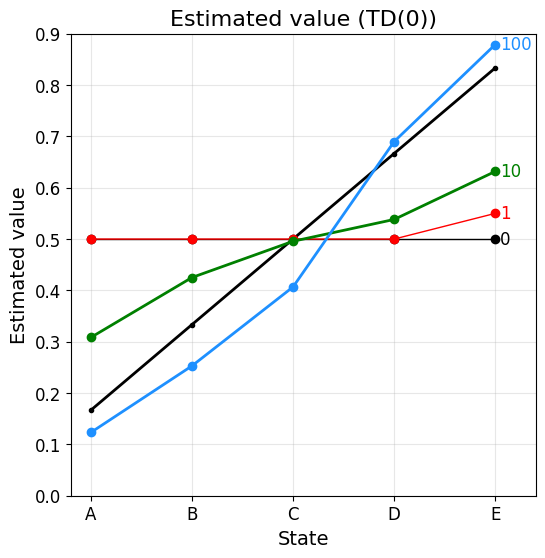

In [9]:
# Run TD(0)
num_episodes = 100
alpha = 0.1
seed = 333

V_final, V_history = td0_prediction(num_episodes, alpha, seed)

# True values for Random Walk (A..E)
TRUE_V = np.array([1 / 6, 2 / 6, 3 / 6, 4 / 6, 5 / 6])

# Episode indices at which we record value estimates
learning_episodes = [0, 1, 10, 100]

# Prepare value estimates at selected episodes
value_estimates_at_episodes = {}

# Episode 0: initial value function (before learning)
V0 = init_V()
value_estimates_at_episodes[0] = V0[1:6]

# Episodes 1, 10, 100: take from TD learning history
for ep in learning_episodes[1:]:
    # V_history[k] contains values after episode k+1 because python count from 0
    value_estimates_at_episodes[ep] = V_history[ep - 1]

# Plot like the book
states = np.arange(1, 6)
labels = ["A", "B", "C", "D", "E"]

plt.figure(figsize=(6, 6))

# True values (black line with dots)
plt.plot(states, TRUE_V, "k.-", linewidth=2, markersize=6, label="True values")

styles = {
    0: {"color": "black", "marker": "o", "linestyle": "-", "linewidth": 1},
    1: {"color": "red", "marker": "o", "linestyle": "-", "linewidth": 1},
    10: {"color": "green", "marker": "o", "linestyle": "-", "linewidth": 2},
    100: {"color": "dodgerblue", "marker": "o", "linestyle": "-", "linewidth": 2},
}

for ep in learning_episodes:
    V = value_estimates_at_episodes[ep]
    plt.plot(states, V, **styles[ep])

    # Annotate episode number near state E (as in the book)
    plt.text(5.05, V[-1], f"{ep}", color=styles[ep]["color"], fontsize=12, va="center")

plt.xticks(states, labels, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.0, 0.9)
plt.xlim(0.8, 5.4)
plt.xlabel("State", fontsize=14)
plt.ylabel("Estimated value", fontsize=14)
plt.title("Estimated value (TD(0))", fontsize=16)

plt.grid(alpha=0.3)
plt.show()


Same plot with Monte-Carlo prediction 

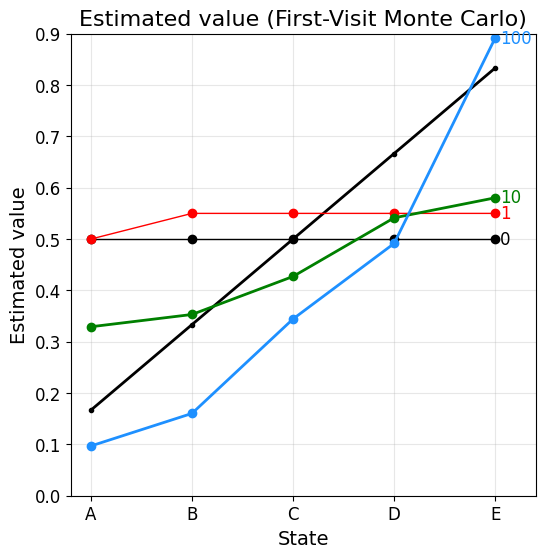

In [10]:
# Run First-Visit Monte Carlo
num_episodes = 100
alpha = 0.1
seed = 333

V_final_mc, V_history_mc = mc_prediction_first_visit(num_episodes, alpha, seed)

# True values for Random Walk (A..E)
TRUE_V = np.array([1 / 6, 2 / 6, 3 / 6, 4 / 6, 5 / 6])

# Episode indices at which we record value estimates
learning_episodes = [0, 1, 10, 100]

# Prepare value estimates at selected episodes
value_estimates_at_episodes = {}

# Episode 0: initial value function (before learning)
V0 = init_V()
value_estimates_at_episodes[0] = V0[1:6]

# Episodes 1, 10, 100: take from Monte Carlo learning history
for ep in learning_episodes[1:]:
    # V_history_mc[k] contains values after episode k+1
    value_estimates_at_episodes[ep] = V_history_mc[ep - 1]

# Plot like the book
states = np.arange(1, 6)
labels = ["A", "B", "C", "D", "E"]

plt.figure(figsize=(6, 6))

# True values (black line with dots)
plt.plot(states, TRUE_V, "k.-", linewidth=2, markersize=6, label="True values")

# Same visual style as TD(0) plot (for fair comparison)
styles = {
    0: {"color": "black", "marker": "o", "linestyle": "-", "linewidth": 1},
    1: {"color": "red", "marker": "o", "linestyle": "-", "linewidth": 1},
    10: {"color": "green", "marker": "o", "linestyle": "-", "linewidth": 2},
    100: {"color": "dodgerblue", "marker": "o", "linestyle": "-", "linewidth": 2},
}

for ep in learning_episodes:
    V = value_estimates_at_episodes[ep]
    plt.plot(states, V, **styles[ep])

    # Annotate episode number near state E
    plt.text(5.05, V[-1], f"{ep}", color=styles[ep]["color"], fontsize=12, va="center")

plt.xticks(states, labels, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.0, 0.9)
plt.xlim(0.8, 5.4)
plt.xlabel("State", fontsize=14)
plt.ylabel("Estimated value", fontsize=14)
plt.title("Estimated value (First-Visit Monte Carlo)", fontsize=16)

plt.grid(alpha=0.3)
plt.show()


## 6. TD(0) vs Monte Carlo Prediction: Quantitative Evaluation and Learning Curves



### 6.1 Evaluation and visualization functions

To compare learning algorithms **TD(0)** and **Monte Carlo prediction**, we
need tools that allow us to **measure errors quantitatively** and **visualize learning dynamics over time**.


**Error metric: RMSE**

To quantify how close an estimated value function `V` is to the true value function
$V_\pi$, we use the **Root Mean Squared Error (RMSE)** computed over the nonterminal
states $A,\dots,E$:
$$
\mathrm{RMSE}(V) \;=\;
\sqrt{\frac{1}{5}\sum_{s \in \{A,\dots,E\}} \big(V(s) - V_\pi(s)\big)^2}.
$$

**Learning curves**

Plotting the RMSE as a function of the episode index yields a **learning curve**
that summarizes the convergence behavior of an algorithm over time.
This is useful when comparing algorithms or studying the effect of hyperparameters such as the step size $\alpha$.


**Value trajectories**

We will also observe how the value estimates of individual states evolve during learning. Plotting $V(A), \dots, V(E)$ as functions of the episode index helps us see:

1. how quickly each state learns from the terminal rewards,

2. whether the learning process is smooth or noisy,

3. how Monte Carlo and TD learning behave differently during training.







In [11]:
TRUE_V = [1 / 6, 2 / 6, 3 / 6, 4 / 6, 5 / 6]


def rmse(V_nonterminal: np.ndarray) -> float:
    """V_nonterminal: array of shape (5,) corresponding to A..E (1..5).

    Args:
        V_nonterminal (np.ndarray): Estimated values for states A..E.

    Returns:
        float: RMSE to true values.

    """
    true = np.array([TRUE_V[i] for i in range(5)])
    return np.sqrt(np.mean((V_nonterminal - true) ** 2))


def plot_rmse_curve(rmse_list: list[float], title: str) -> None:
    """Plot RMSE curve over episodes."""
    plt.figure()
    plt.plot(rmse_list)
    plt.xlabel("Episode")
    plt.ylabel("RMSE vs true V")
    plt.title(title)
    plt.show()


def plot_value_trajectories(V_hist: np.ndarray, title: str) -> None:
    """Plot value estimates of A..E over episodes.

    Args:
        V_hist (np.ndarray): Array of shape (num_episodes, 5) with value estimates.
        title (str): Title of the plot.

    """
    plt.figure()
    for i, name in enumerate(["A", "B", "C", "D", "E"]):
        plt.plot(V_hist[:, i], label=f"V({name})")
    # True lines (optional, helps visually)
    true = [TRUE_V[i] for i in range(5)]
    for i, _name in enumerate(["A", "B", "C", "D", "E"]):
        plt.axhline(true[i], linestyle="--")
    plt.xlabel("Episode")
    plt.ylabel("Value estimate")
    plt.title(title)
    plt.legend()
    plt.show()


### 6.2 Compare learning dynamics and error convergence

In this subsection, we compare **Monte Carlo prediction** and **TD(0) prediction** on the Random Walk environment under the same experimental conditions.

Both algorithms are run:
- with the same number of episodes,
- with the same constant step size $\alpha$,
- and using the same random seed = 333 for reproducibility.


We focus on 

1. **Value trajectories**  
   We plot how the estimated values $V(A), \dots, V(E)$ evolve over episodes for each
   algorithm.  This allows us to observe:
   - how fast learning progresses,
   - how stable or noisy the updates are,
   - and how information propagates through the states.

2. **Prediction error (RMSE)**  
   We compute the **Root Mean Squared Error (RMSE)** with respect to the true value
   function after each episode.  
   Plotting RMSE over time provides a quantitative measure of convergence speed and
   stability.




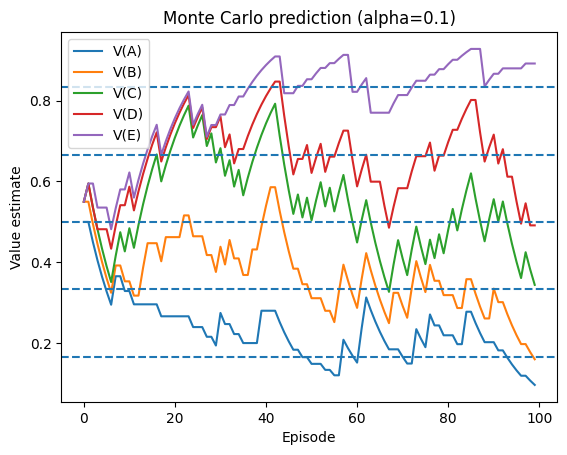

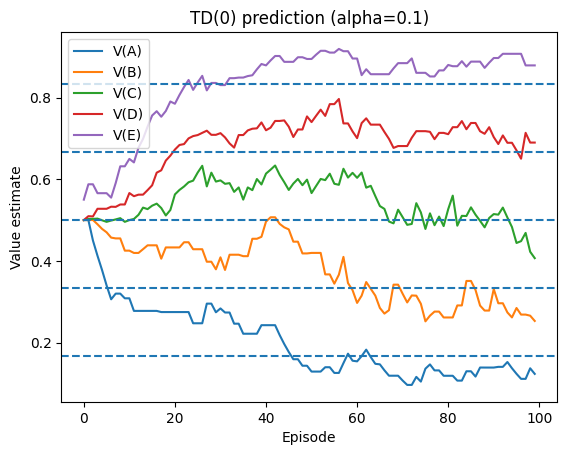

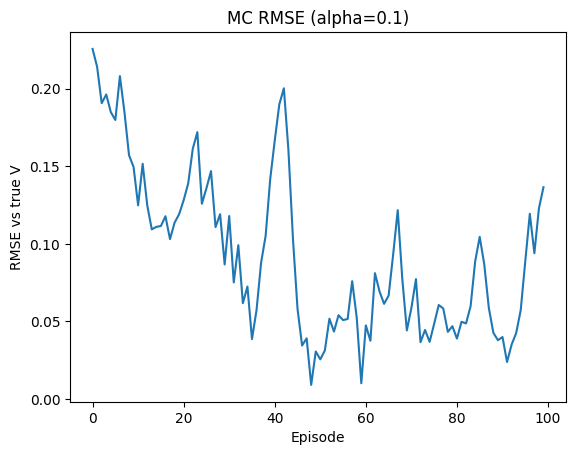

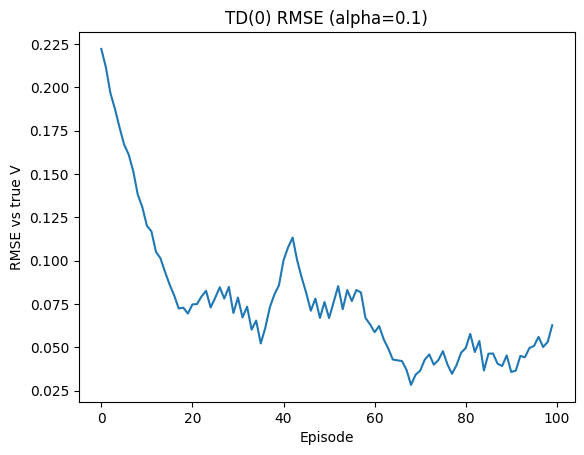

In [12]:
num_episodes = 100
alpha = 0.1

V_mc, hist_mc = mc_prediction_first_visit(
    num_episodes=num_episodes,
    alpha=alpha,
    seed=333,
)
V_td, hist_td = td0_prediction(num_episodes=num_episodes, alpha=alpha, seed=333)

plot_value_trajectories(hist_mc, f"Monte Carlo prediction (alpha={alpha})")
plot_value_trajectories(hist_td, f"TD(0) prediction (alpha={alpha})")

rmse_mc = [rmse(hist_mc[e]) for e in range(num_episodes)]
rmse_td = [rmse(hist_td[e]) for e in range(num_episodes)]
plot_rmse_curve(rmse_mc, f"MC RMSE (alpha={alpha})")
plot_rmse_curve(rmse_td, f"TD(0) RMSE (alpha={alpha})")


**Exercise 4.** 

Observe the plots produced in the previous cell (value trajectories and RMSE
curves), answer the following questions.

1. **Convergence rate of the learning**  
   Which algorithm approaches the true value function more quickly? 

2. **Stability of learning**  
   Which algorithm exhibits more variability (noise) in its value estimates?




#### 1. Convergence Rate of the Learning

**Algorithm: TD(0)**

Observation:

- RMSE Curves: In the `TD(0) RMSE` plot, the error decreases more rapidly and consistently during the initial episodes ($0–20$).

- Value Trajectories: In the `TD(0) prediction` plot, the estimates for the central states (specifically $V(C)$) begin to gravitate toward the true value ($0.5$) almost immediately.

- Reasoning: `TD(0)` learns from every single transition (step-by-step) by bootstrapping. This allows it to update its estimates much more frequently than MC, which must wait until the end of an entire episode to make a single update.

#### 2. Stability of Learning

**Algorithm: Monte Carlo (MC) exhibits more variability.**

Observation:

- Noise Level: The `Monte Carlo prediction` plot shows significant "spikes" and high-frequency oscillations. Even after 80 episodes, the estimates for $V(D)$ and $V(E)$ fluctuate wildly above and below the dashed target lines.

- RMSE Fluctuations: The `MC RMSE` curve is much noisier, with large peaks (e.g., around episode $40$) where the error nearly returns to its initial state.

- Theoretical Basis: This is due to the high variance of the full return $G_t$​. Since `MC` updates depend on the cumulative sequence of all random actions and transitions until the end of an episode, a single "lucky" or "unlucky" episode can drastically shift the value estimate. `TD(0)` has lower variance because it only depends on one random step and the current estimate of the next state.

### 6.3 Effect of the Step Size $\alpha$: Speed vs Stability

In the previous experiments, we compared Monte Carlo prediction and TD(0) using a
fixed step size $\alpha$.   However, the choice of $\alpha$ has a crucial impact on **learning speed** and **stability** for both algorithms.

A large step size may lead to fast initial learning but unstable or oscillatory
behavior, while a small step size typically yields smoother learning at the cost of
slower convergence.

To obtain a reliable comparison, we:
- repeat each experiment over many independent runs,
- compute the RMSE at each episode,
- and average the RMSE curves across runs.





The goal of `average_rmse_over_runs` in the following cell is to compute, for each value of the step size $\alpha$, the *average RMSE curve* over a fixed number of episodes and runs.

The function returns a dictionary:
$$
\text{results}[\alpha] = \big(\text{average RMSE at episode } 1,\dots,\text{episode } T\big).
$$

Inputs of this function

- `method`:  
  A string indicating which algorithm to evaluate:
  - `"mc"` for First-Visit Monte Carlo prediction,
  - `"td"` for TD(0) prediction.

- `alphas`:  
  A list (or array) of step-size values \(\alpha\) to test.

- `num_episodes`:  
  Number of episodes per run (default: 100).

- `num_runs`:  
  Number of independent runs used for averaging (default: 100).




In [13]:
def average_rmse_over_runs(
    method: str,
    alphas: list[float],
    num_episodes: int = 100,
    num_runs: int = 100,
) -> dict[float, np.ndarray]:
    """Compute average RMSE curves over multiple independent runs.

    Args:
        method (str): "mc" or "td"
        alphas (list[float]): List of step sizes to evaluate.
        num_episodes (int): Number of episodes per run.
        num_runs (int): Number of independent runs.

    Returns:
        dict[float, np.ndarray]: Dictionary mapping each alpha to its average RMSE curve.

    """
    results = {}  # This dictionary will store one averaged RMSE curve per step size alpha

    for alpha in alphas:  # Loop over step sizes
        rmse_runs = np.zeros(
            (num_runs, num_episodes),
        )  # For each alpha, we create a matrix where:
        # rows correspond to independent runs,
        # columns correspond to episodes.

        for run in range(num_runs):  # Repeat independent runs
            seed = (
                1000 * run + 7
            )  # Each run uses a different random seed to ensure independence, while remaining reproducible.

            # Run the chosen learning algorithm, we run either MC or TD(0) and obtain
            # hist: a matrix of shape (num_episodes, 5) containing value estimates for states A, B, ..., E after each episode.
            if method == "mc":
                _, hist = mc_prediction_first_visit(
                    num_episodes=num_episodes,
                    alpha=alpha,
                    seed=seed,
                )
            elif method == "td":
                _, hist = td0_prediction(
                    num_episodes=num_episodes,
                    alpha=alpha,
                    seed=seed,
                )
            else:
                msg = "Method must be 'mc' or 'td'"
                raise ValueError(msg)

            for e in range(
                num_episodes,
            ):  # For each episode, we compute the RMSE between the estimated values and the true values
                rmse_runs[run, e] = rmse(
                    hist[e],
                )  # This fills one row (run) of rmse_runs.

        results[alpha] = rmse_runs.mean(
            axis=0,
        )  # Average over runs to obtain a smooth learning curve.

    return results


# Output: The function returns a dictionary where: each key is a step size alpha,
# and each value is a NumPy array of length num_episodes containing the average RMSE at each episode.


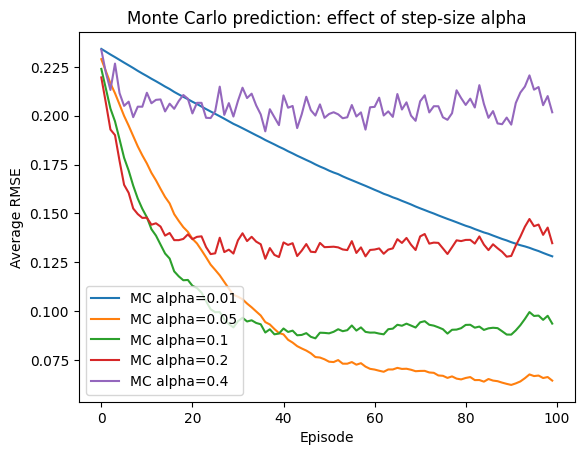

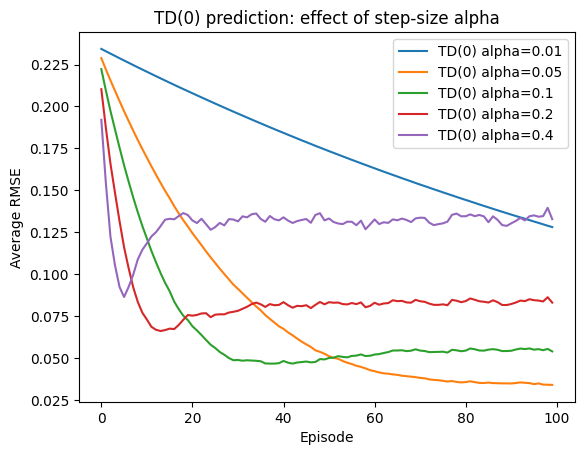

In [14]:
alphas = [0.01, 0.05, 0.1, 0.2, 0.4]
num_episodes = 100
num_runs = 200

avg_mc = average_rmse_over_runs(
    "mc",
    alphas,
    num_episodes=num_episodes,
    num_runs=num_runs,
)
avg_td = average_rmse_over_runs(
    "td",
    alphas,
    num_episodes=num_episodes,
    num_runs=num_runs,
)

# Plot averaged RMSE curves
plt.figure()
for a in alphas:
    plt.plot(avg_mc[a], label=f"MC alpha={a}")
plt.xlabel("Episode")
plt.ylabel("Average RMSE")
plt.title("Monte Carlo prediction: effect of step-size alpha")
plt.legend()
plt.show()

plt.figure()
for a in alphas:
    plt.plot(avg_td[a], label=f"TD(0) alpha={a}")
plt.xlabel("Episode")
plt.ylabel("Average RMSE")
plt.title("TD(0) prediction: effect of step-size alpha")
plt.legend()
plt.show()


**Effect of the Step Size $\alpha$**

- **Speed–stability trade-off**  
  Larger values of $\alpha$ typically lead to faster initial error reduction, but
  also introduce higher variability and potential oscillations.  
  Smaller values of $\alpha$ result in slower but more stable convergence.

- **TD(0) vs Monte Carlo**  
  For the same step size, TD(0) generally achieves lower average RMSE in the early
  stages of learning. This reflects its ability to update value estimates after each
  transition through bootstrapping.  Monte Carlo prediction, which relies on complete returns, tends to learn more slowly and exhibits higher variance.


